
# Non-Stationarity Analysis Notebook (TimeBridge Benchmarks)

This notebook provides a clean, reproducible pipeline to **diagnose non-stationarity** on common LTSF datasets used in the TimeBridge paper.

**What you'll get:**
- Rolling mean/std visualizations
- ADF & KPSS tests (raw and after first-differencing)
- Optional Engle–Granger cointegration test (pairwise across first `K` channels)
- Aggregated tables (CSV) per dataset for your report

> Datasets supported: ETT (ETTh1/ETTh2/ETTm1/ETTm2), Electricity, Weather, Traffic, Solar, PeMS, optional finance (CSI 500, S&P 500).



## 0. Prerequisites
Make sure the datasets are in a local folder similar to:
```
dataset/
  ETT-small/ETTh1.csv
  ETT-small/ETTh2.csv
  ETT-small/ETTm1.csv
  ETT-small/ETTm2.csv
  Electricity/electricity.csv
  Traffic/traffic.csv
  Weather/weather.csv
  Solar/solar_AL.csv  # name may vary
  PeMS/PeMS03.csv     # examples
```
Install packages if needed:
```bash
pip install pandas numpy matplotlib statsmodels arch
```


In [22]:
import pandas as pd 
# ==== Single self-contained setup cell ====
from pathlib import Path
import os, itertools, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss, coint

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10, 4)

# -- Find the project root by walking up until we see 'dataset/'
def find_project_root(max_up=8):
    p = Path.cwd()
    for _ in range(max_up):
        if (p / "dataset").exists():
            return p
        p = p.parent
    return Path.cwd()

PROJECT_ROOT = find_project_root()
DATA_ROOT    = PROJECT_ROOT / "dataset"                     # <-- Path (not str)
EXPORT_DIR   = PROJECT_ROOT / "exports" / "nonstationarity" # <-- Path
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("EXPORT_DIR:", EXPORT_DIR)

PROJECT_ROOT: c:\Users\badre\OneDrive\Documents\TimeBridge-Enhanced-NonStationnary-MTS
DATA_ROOT: c:\Users\badre\OneDrive\Documents\TimeBridge-Enhanced-NonStationnary-MTS\dataset
EXPORT_DIR: c:\Users\badre\OneDrive\Documents\TimeBridge-Enhanced-NonStationnary-MTS\exports\nonstationarity


In [23]:
def _coerce_numeric(df, cols):
    for c in cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def load_dataset(name):
    """
    Returns (df, time_col, value_cols).
    Supports your tree:
      dataset/
        ETT-small/ETTh1.csv ...
        electricity/electricity.csv
        weather/weather.csv
        traffic/traffic.csv
        Solar/solar_AL.txt   (or Solar/solar.csv if you add it)
        PeMS/PEMS03.npz ... (or CSV if present)
        exchange_rate/exchange_rate.csv
    """
    nm = name.lower()

    # ---- ETT (exact filenames; camel case)
    if nm in {"etth1","etth2","ettm1","ettm2"}:
        name_map = {"etth1":"ETTh1","etth2":"ETTh2","ettm1":"ETTm1","ettm2":"ETTm2"}
        path = DATA_ROOT / "ETT-small" / f"{name_map[nm]}.csv"
        if not path.exists():
            raise FileNotFoundError(f"ETT file not found: {path}")
        df = pd.read_csv(path)
        time_col = "date"
        value_cols = [c for c in df.columns if c != time_col]
        return _coerce_numeric(df, value_cols), time_col, value_cols

    # ---- Electricity (lowercase folder)
    if nm == "electricity":
        path = DATA_ROOT / "electricity" / "electricity.csv"
        df = pd.read_csv(path)
        time_col = df.columns[0]
        value_cols = [c for c in df.columns if c != time_col]
        return _coerce_numeric(df, value_cols), time_col, value_cols

    # ---- Weather (lowercase folder)
    if nm == "weather":
        path = DATA_ROOT / "weather" / "weather.csv"
        df = pd.read_csv(path)
        time_col = df.columns[0]
        value_cols = [c for c in df.columns if c != time_col]
        return _coerce_numeric(df, value_cols), time_col, value_cols

    # ---- Traffic (lowercase folder)
    if nm == "traffic":
        path = DATA_ROOT / "traffic" / "traffic.csv"
        df = pd.read_csv(path)
        time_col = df.columns[0]
        value_cols = [c for c in df.columns if c != time_col]
        return _coerce_numeric(df, value_cols), time_col, value_cols

    # ---- Solar: your file is solar_AL.txt (csv content in .txt)
    if nm in {"solar","solar-energy","solar_energy"}:
        candidates = [
            DATA_ROOT / "Solar" / "solar_AL.txt",
            DATA_ROOT / "Solar" / "solar.csv",
        ]
        for p in candidates:
            if p.exists():
                # try comma first; if it fails, let pandas sniff
                try:
                    df = pd.read_csv(p)
                except Exception:
                    df = pd.read_csv(p, sep=None, engine="python")
                time_col = df.columns[0]
                value_cols = [c for c in df.columns if c != time_col]
                return _coerce_numeric(df, value_cols), time_col, value_cols
        raise FileNotFoundError("Solar file not found. Tried: " + " | ".join(map(str, candidates)))

    # ---- Exchange rate (optional)
    if nm in {"exchange_rate","exchange-rate"}:
        path = DATA_ROOT / "exchange_rate" / "exchange_rate.csv"
        df = pd.read_csv(path)
        time_col = df.columns[0]
        value_cols = [c for c in df.columns if c != time_col]
        return _coerce_numeric(df, value_cols), time_col, value_cols

    # ---- PeMS: try CSV, then NPZ (PEMS03.npz etc.)
    if nm.startswith("pems"):
        csv_path = DATA_ROOT / "PeMS" / f"{name}.csv"
        npz_path = DATA_ROOT / "PeMS" / f"{name.upper()}.npz"
        if csv_path.exists():
            df = pd.read_csv(csv_path)
            time_col = df.columns[0]
            value_cols = [c for c in df.columns if c != time_col]
            return _coerce_numeric(df, value_cols), time_col, value_cols
        if npz_path.exists():
            data = np.load(npz_path, allow_pickle=True)
            # try common keys; fallback to first array
            arr = data.get("data")
            if arr is None:
                # e.g., np.savez default keys: arr_0, arr_1, ...
                for k in data.files:
                    if data[k].ndim >= 2:
                        arr = data[k]; break
            if arr is None:
                raise ValueError(f"No 2D array found inside {npz_path}")
            # timestamps if provided
            if "timestamps" in data:
                t = pd.to_datetime(data["timestamps"])
            else:
                t = pd.date_range("2000-01-01", periods=arr.shape[0], freq="5min")
            cols = [f"v{i}" for i in range(arr.shape[1])]
            df = pd.DataFrame(arr, columns=cols)
            df.insert(0, "time", t)
            time_col = "time"
            value_cols = cols
            return _coerce_numeric(df, value_cols), time_col, value_cols
        raise FileNotFoundError(f"PeMS file not found: {csv_path} or {npz_path}")

    raise ValueError(f"Unknown dataset name or missing file: {name}")

# ----------------------------
# Tests
# ----------------------------
def adf_test(x):
    x = pd.Series(x).dropna()
    if len(x) < 10:
        return np.nan
    _, pvalue, *_ = adfuller(x, autolag="AIC")
    return pvalue

def kpss_test(x, regression="c"):
    x = pd.Series(x).dropna()
    if len(x) < 10:
        return np.nan
    try:
        _, pvalue, *_ = kpss(x, regression=regression, nlags="auto")
    except Exception:
        pvalue = np.nan
    return pvalue

def differenced(x):
    return pd.Series(x).diff().dropna()

def analyze_series(x):
    """Return ADF/KPSS (level + trend) p-values for raw and first-diff."""
    raw_adf         = adf_test(x)
    raw_kpss_level  = kpss_test(x, regression="c")
    raw_kpss_trend  = kpss_test(x, regression="ct")
    dx              = differenced(x)
    d_adf           = adf_test(dx)
    d_kpss_level    = kpss_test(dx, regression="c")
    d_kpss_trend    = kpss_test(dx, regression="ct")
    return {
        "ADF p (raw)": raw_adf,
        "KPSS level p (raw)": raw_kpss_level,
        "KPSS trend p (raw)": raw_kpss_trend,
        "ADF p (diff1)": d_adf,
        "KPSS level p (diff1)": d_kpss_level,
        "KPSS trend p (diff1)": d_kpss_trend,
    }

def cointegration_scan(df, cols, max_pairs=20):
    """Pairwise Engle–Granger with NaN-safe alignment; returns p-values."""
    results = []
    pairs = list(itertools.combinations(cols[:min(len(cols), 50)], 2))  # limit for speed
    for i, j in pairs[:max_pairs]:
        x, y = _aligned_pair(df[i], df[j])
        if len(x) < 10 or len(y) < 10:
            pvalue = np.nan
        else:
            try:
                pvalue = coint(x, y, trend="c")[1]
            except Exception:
                pvalue = np.nan
        results.append({"var1": i, "var2": j, "EG p": pvalue})
    return pd.DataFrame(results)

# ----------------------------
# Plots & runner
# ----------------------------
def rolling_plots(df, time_col, var, win=168, title_prefix=""):
    t = pd.to_datetime(df[time_col], errors="coerce")
    x = pd.to_numeric(df[var], errors="coerce")
    x = x.where(np.isfinite(x))
    n = x.dropna().shape[0]
    w = _safe_window(win, len(x))

    roll_mean = x.rolling(w).mean()
    roll_std  = x.rolling(w).std()

    # Rolling mean
    plt.figure()
    plt.plot(t, x)
    plt.plot(t, roll_mean)
    plt.title(f"{title_prefix}{var} — raw & rolling mean (win={w})")
    plt.xlabel("time"); plt.ylabel(var)
    plt.tight_layout()
    plt.show()

    # Rolling std
    plt.figure()
    plt.plot(t, roll_std)
    plt.title(f"{title_prefix}{var} — rolling std (win={w})")
    plt.xlabel("time"); plt.ylabel("std")
    plt.tight_layout()
    plt.show()

def run_dataset(name, variables=3, win=168, do_coint=True, coint_pairs=10):
    df, tcol, vcols = load_dataset(name)

    # numeric-only columns
    vcols = [c for c in vcols if pd.api.types.is_numeric_dtype(df[c])]
    if not vcols:
        raise ValueError(f"No numeric value columns found in {name}")

    take = vcols[:min(variables, len(vcols))]

    rows = []
    for col in take:
        rolling_plots(df, tcol, col, win=win, title_prefix=f"[{name}] ")
        stats = analyze_series(df[col].values)
        stats.update({"dataset": name, "variable": col})
        rows.append(stats)

    res = pd.DataFrame(rows)
    out_csv = os.path.join(EXPORT_DIR, f"{name}_stationarity_summary.csv")
    res.to_csv(out_csv, index=False)

    if do_coint and len(vcols) >= 2:
        eg = cointegration_scan(df, vcols, max_pairs=coint_pairs)
        eg_csv = os.path.join(EXPORT_DIR, f"{name}_cointegration_pairs.csv")
        eg.to_csv(eg_csv, index=False)
        print(f"Cointegration pairs saved: {eg_csv}")

    print(f"Summary saved: {out_csv}")
    return res


In [18]:
import glob
print("ETT:", glob.glob(str(DATA_ROOT / "ETT-small" / "*.csv")))
print("Solar exists?:", (DATA_ROOT / "Solar" / "solar_AL.txt").exists())
print("PeMS NPZ:", glob.glob(str(DATA_ROOT / "PeMS" / "*.npz")))


ETT: ['c:\\Users\\badre\\OneDrive\\Documents\\TimeBridge-Enhanced-NonStationnary-MTS\\dataset\\ETT-small\\ETTh1.csv', 'c:\\Users\\badre\\OneDrive\\Documents\\TimeBridge-Enhanced-NonStationnary-MTS\\dataset\\ETT-small\\ETTh2.csv', 'c:\\Users\\badre\\OneDrive\\Documents\\TimeBridge-Enhanced-NonStationnary-MTS\\dataset\\ETT-small\\ETTm1.csv', 'c:\\Users\\badre\\OneDrive\\Documents\\TimeBridge-Enhanced-NonStationnary-MTS\\dataset\\ETT-small\\ETTm2.csv']
Solar exists?: True
PeMS NPZ: ['c:\\Users\\badre\\OneDrive\\Documents\\TimeBridge-Enhanced-NonStationnary-MTS\\dataset\\PeMS\\PEMS03.npz', 'c:\\Users\\badre\\OneDrive\\Documents\\TimeBridge-Enhanced-NonStationnary-MTS\\dataset\\PeMS\\PEMS04.npz', 'c:\\Users\\badre\\OneDrive\\Documents\\TimeBridge-Enhanced-NonStationnary-MTS\\dataset\\PeMS\\PEMS07.npz', 'c:\\Users\\badre\\OneDrive\\Documents\\TimeBridge-Enhanced-NonStationnary-MTS\\dataset\\PeMS\\PEMS08.npz']



## 1. Quick Start (ETTh1 example)
This runs rolling diagnostics + ADF/KPSS on the first 3 variables and saves CSV summaries.


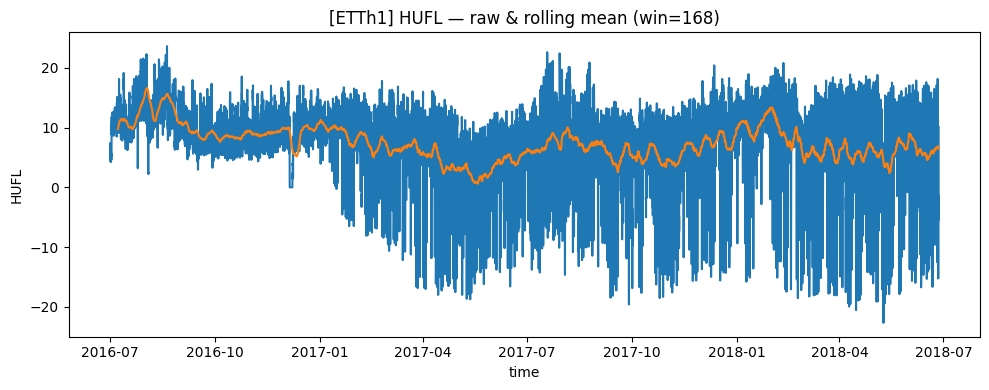

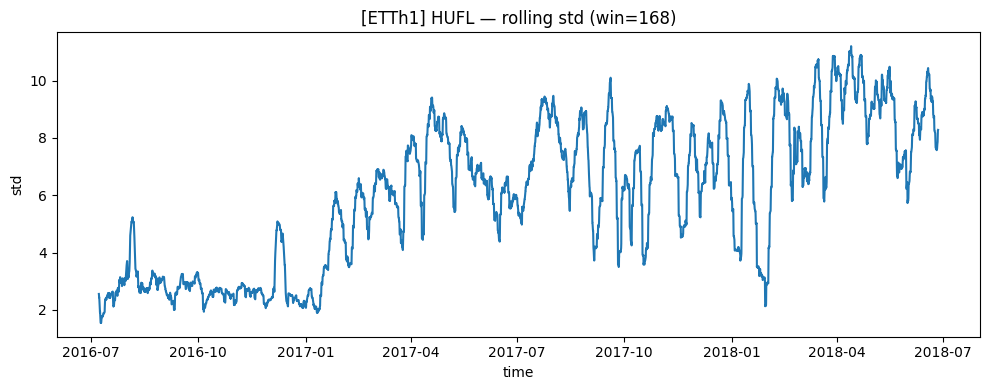

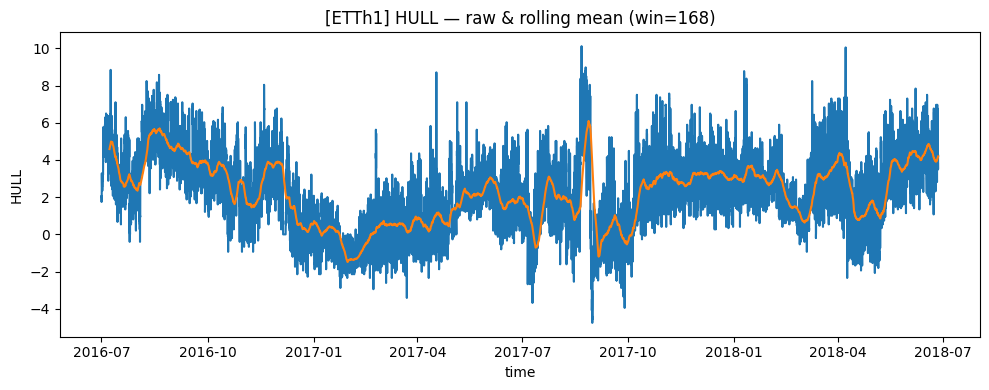

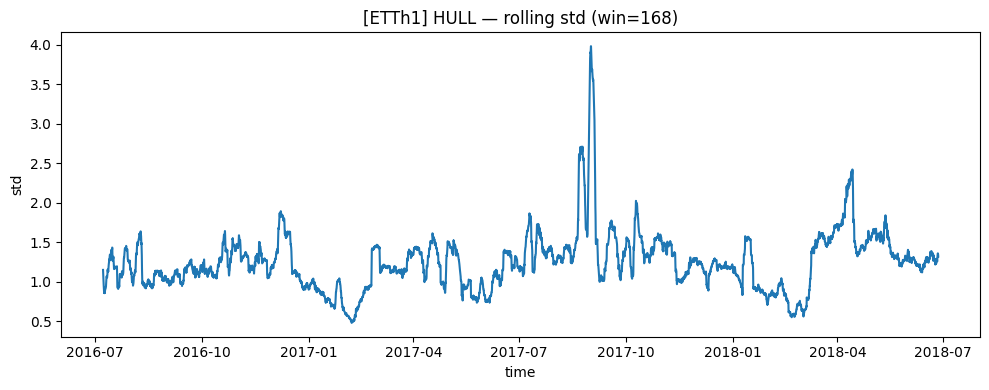

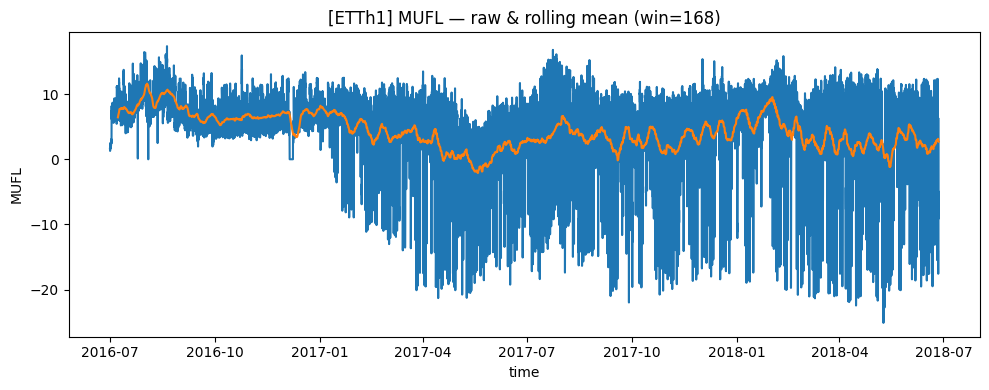

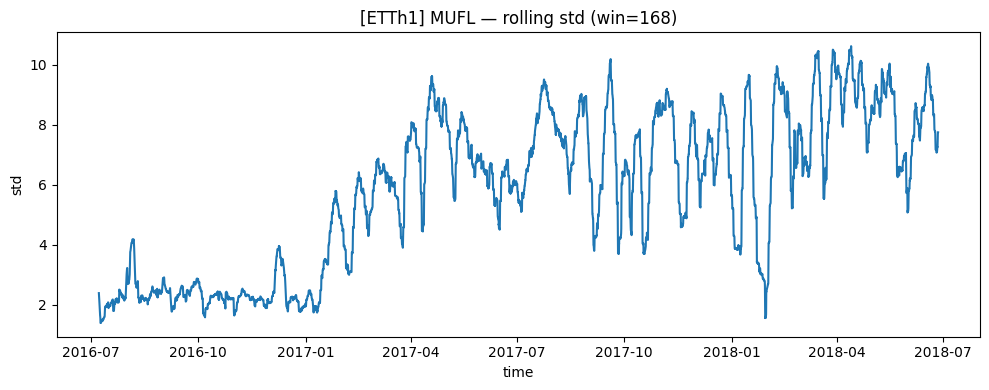

Cointegration pairs saved: c:\Users\badre\OneDrive\Documents\TimeBridge-Enhanced-NonStationnary-MTS\exports\nonstationarity\ETTh1_cointegration_pairs.csv
Summary saved: c:\Users\badre\OneDrive\Documents\TimeBridge-Enhanced-NonStationnary-MTS\exports\nonstationarity\ETTh1_stationarity_summary.csv


In [24]:

_ = run_dataset("ETTh1", variables=3, win=168, do_coint=True, coint_pairs=10)



## 2. Batch Mode (loop over datasets)
Uncomment to run multiple datasets in one go.


In [ ]:

# datasets = ["ETTh1","ETTh2","ETTm1","ETTm2","Electricity","Traffic","Weather","Solar"]
# for d in datasets:
#     try:
#         print("\n===", d, "===")
#         run_dataset(d, variables=3, win=168, do_coint=True, coint_pairs=10)
#     except Exception as e:
#         print("[WARN]", d, "->", e)



## 3. Interpreting Results (Rule-of-Thumb)
- **Non-stationary**: ADF p ≥ 0.05 **and** KPSS p < 0.05 (level or trend) on raw series.
- **After differencing**: ADF p < 0.05 **and** KPSS p ≥ 0.10 → stationarity achieved.
- **Cointegration**: EG p < 0.05 indicates long-run equilibrium between a pair.

> Tip: Avoid over-differencing when variables are cointegrated (can destroy long-run structure).


In [26]:
# Example: test stationarity for one ETT variable

df, tcol, vcols = load_dataset("ETTh1")
var = vcols[0]  # pick first column (e.g., 'OT')
x = df[var].values

print(f"Testing variable: {var}")

res = analyze_series(x)
for k, v in res.items():
    print(f"{k:<25}: {v:.4f}")



Testing variable: HUFL
ADF p (raw)              : 0.0000
KPSS level p (raw)       : 0.0100
KPSS trend p (raw)       : 0.0100
ADF p (diff1)            : 0.0000
KPSS level p (diff1)     : 0.1000
KPSS trend p (diff1)     : 0.1000


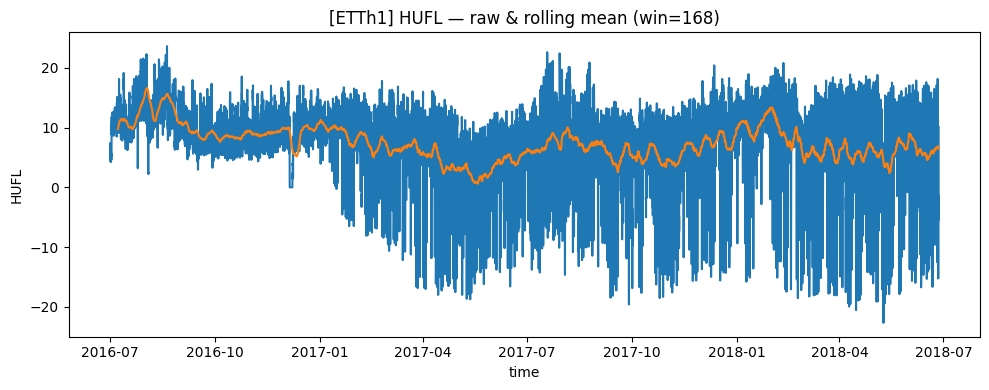

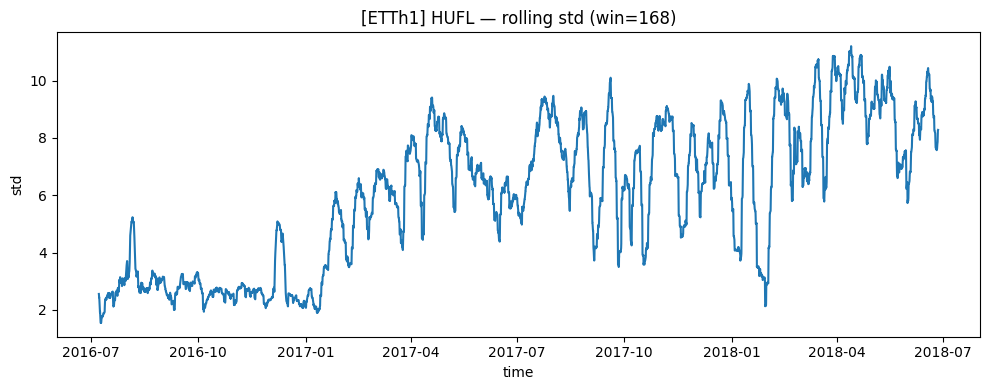

In [27]:
rolling_plots(df, tcol, var, win=168, title_prefix="[ETTh1] ")


In [28]:
from statsmodels.tsa.stattools import kpss
stat, pval, lags, crit = kpss(df[var].dropna(), regression='ct', nlags='auto')
print("KPSS trend test p-value:", pval)


KPSS trend test p-value: 0.01


## 3. Statistical Tests for Non-Stationarity

We apply two complementary tests:

| Test | Null Hypothesis | Detects |
|------|------------------|----------|
| **ADF (Augmented Dickey–Fuller)** | Data has a *unit root* → non-stationary | Trend / stochastic trend |
| **KPSS (Kwiatkowski–Phillips–Schmidt–Shin)** | Data is *level/trend stationary* | Mean / trend stationarity |

These have opposite nulls:
- If **ADF fails** to reject and **KPSS rejects** → strong non-stationarity.  
- After differencing, both should indicate stationarity.


In [38]:
df, tcol, vcols = load_dataset("ETTh1")

results = []
for var in vcols[:7]:  # test first 3 series
    x = df[var].values
    stats = analyze_series(x)
    stats.update({"variable": var})
    results.append(stats)

pd.DataFrame(results)


,ADF p (raw),KPSS level p (raw),KPSS trend p (raw),ADF p (diff1),KPSS level p (diff1),KPSS trend p (diff1),variable
0,9.250276e-14,0.01,0.01,0.0,0.1,0.1,HUFL
1,1.016534e-05,0.01,0.01,0.0,0.1,0.1,HULL
2,6.098079e-14,0.01,0.01,0.0,0.1,0.1,MUFL
3,2.612875e-05,0.01,0.01,0.0,0.1,0.1,MULL
4,4.728964e-07,0.01,0.01,0.0,0.1,0.1,LUFL
5,6.132123e-05,0.01,0.01,0.0,0.1,0.1,LULL
6,8.301649e-03,0.01,0.01,0.0,0.1,0.1,OT


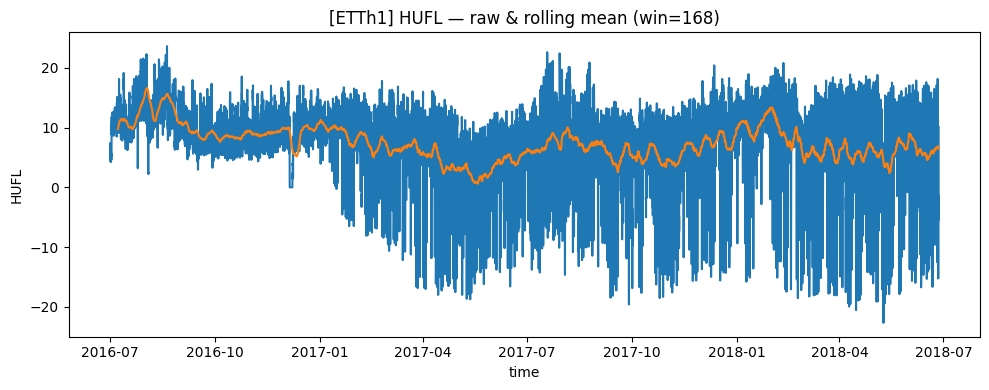

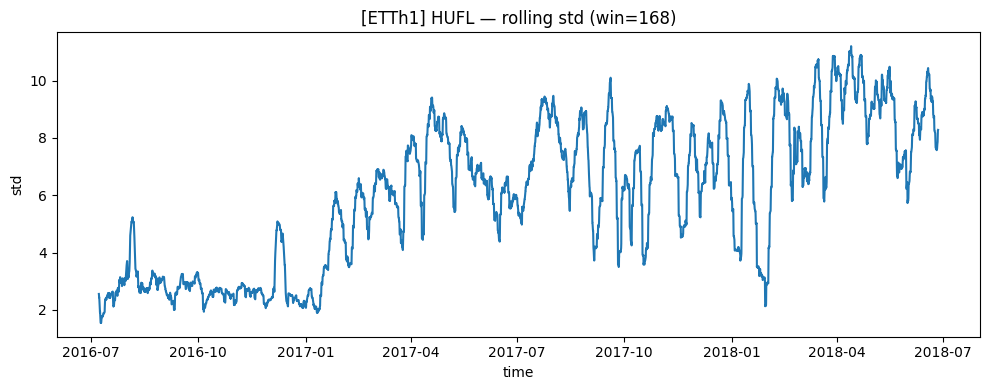

In [30]:
rolling_plots(df, tcol, "HUFL", win=168, title_prefix="[ETTh1] ")


In [31]:
df, tcol, vcols = load_dataset("ETTh1")
eg = cointegration_scan(df, vcols, max_pairs=5)
eg.head()


,var1,var2,EG p
0,HUFL,HULL,2.237873e-13
1,HUFL,MUFL,2.663161e-11
2,HUFL,MULL,4.276101e-13
3,HUFL,LUFL,2.066211e-12
4,HUFL,LULL,1.250649e-12


In [32]:
datasets = ["ETTh1", "ETTm1", "electricity", "traffic", "weather"]


In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

all_results = []

for name in datasets:
    print(f"\nAnalyzing {name} ...")
    try:
        df, tcol, vcols = load_dataset(name)
        take = vcols[:min(3, len(vcols))]  # limit to 3 vars for speed
        for var in take:
            stats = analyze_series(df[var].values)
            stats.update({"dataset": name, "variable": var})
            all_results.append(stats)
    except Exception as e:
        print(f" Skipping {name}: {e}")

res_all = pd.DataFrame(all_results)
res_all.head()



Analyzing ETTh1 ...

Analyzing ETTm1 ...

Analyzing electricity ...

Analyzing traffic ...

Analyzing weather ...


,ADF p (raw),KPSS level p (raw),KPSS trend p (raw),ADF p (diff1),KPSS level p (diff1),KPSS trend p (diff1),dataset,variable
0,9.250276e-14,0.01,0.01,0.0,0.1,0.1,ETTh1,HUFL
1,1.016534e-05,0.01,0.01,0.0,0.1,0.1,ETTh1,HULL
2,6.098079e-14,0.01,0.01,0.0,0.1,0.1,ETTh1,MUFL
3,0.000000e+00,0.01,0.01,0.0,0.1,0.1,ETTm1,HUFL
4,7.246693e-22,0.01,0.01,0.0,0.1,0.1,ETTm1,HULL


Seaborn version: 0.13.2


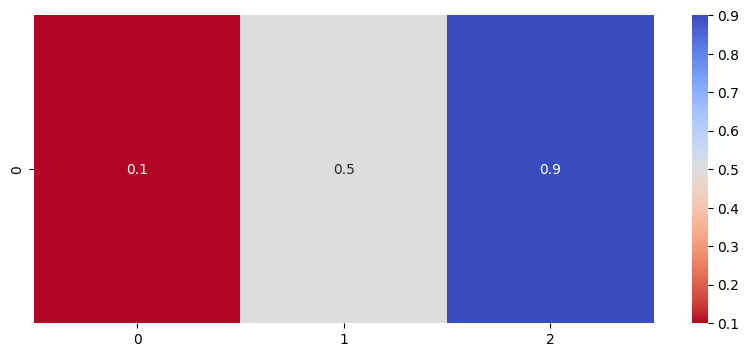

In [35]:
import seaborn as sns, matplotlib.pyplot as plt
print("Seaborn version:", sns.__version__)

# quick test plot
sns.heatmap([[0.1, 0.5, 0.9]], annot=True, cmap="coolwarm_r")
plt.show()


In [36]:
# Select only key columns for visual comparison
cols_for_heatmap = [
    "ADF p (raw)", "KPSS level p (raw)", "KPSS trend p (raw)",
    "ADF p (diff1)", "KPSS level p (diff1)", "KPSS trend p (diff1)"
]

# Create a pivot table (datasets × tests)
heatmap_df = (
    res_all.groupby("dataset")[cols_for_heatmap]
    .mean()
    .sort_index()
)

# Normalize (clip between 0 and 1 for better color scale)
heatmap_df = heatmap_df.clip(0, 1)
heatmap_df


,ADF p (raw),KPSS level p (raw),KPSS trend p (raw),ADF p (diff1),KPSS level p (diff1),KPSS trend p (diff1)
dataset,,,,,,
ETTh1,3.388445e-06,0.01,0.010000,0.0,0.1,0.1
ETTm1,2.415564e-22,0.01,0.010000,0.0,0.1,0.1
electricity,6.202066e-06,0.01,0.010000,0.0,0.1,0.1
traffic,5.930993e-28,0.04,0.046863,0.0,0.1,0.1
weather,4.796036e-13,0.01,0.010882,0.0,0.1,0.1


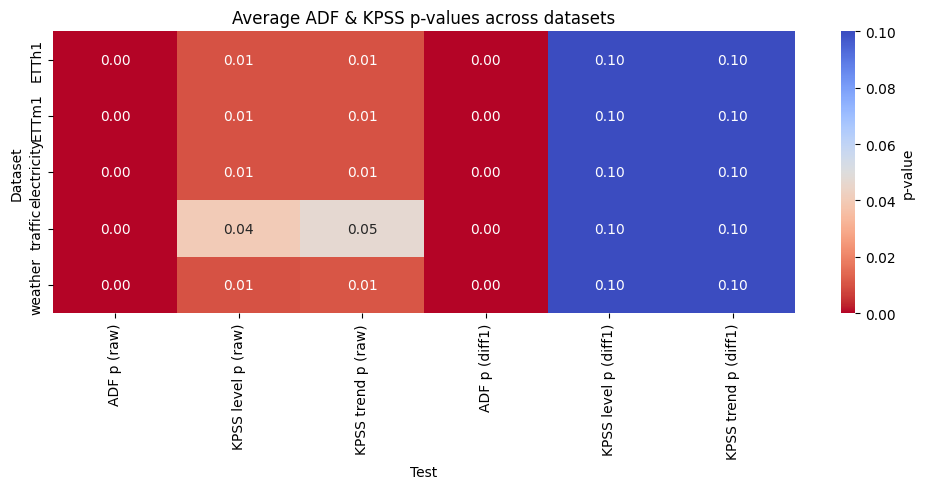

In [37]:
plt.figure(figsize=(10, 5))
sns.heatmap(
    heatmap_df,
    annot=True,
    cmap="coolwarm_r",
    cbar_kws={"label": "p-value"},
    fmt=".2f"
)
plt.title("Average ADF & KPSS p-values across datasets")
plt.ylabel("Dataset")
plt.xlabel("Test")
plt.tight_layout()
plt.show()


## ETT Stationarity Summary (ETTm1, ETTm2, ETTh1, ETTh2)

We evaluate the 4 ETT datasets (Dim = 7 variables each) at their native sampling:
- **ETTm1, ETTm2**: 15 min
- **ETTh1, ETTh2**: 1 hour

Metrics:
- **ADF_score (Σ log10 p)**: sum of log10 ADF p-values over the 7 variables  
  (more negative ⇒ stronger evidence of stationarity by ADF).
- **EG_count (p<0.05)**: number of Engle–Granger cointegrated pairs among the 21 possible (C(7,2)).

We also visualize average p-values (raw and after first difference) as a heatmap in log10 scale.


In [39]:
import numpy as np
import pandas as pd
from itertools import combinations
from statsmodels.tsa.stattools import adfuller, coint

ett_list = [
    ("ETTm1", "15 min"),
    ("ETTm2", "15 min"),
    ("ETTh1", "1 hour"),
    ("ETTh2", "1 hour"),
]

def adf_logsum(series_list):
    """Sum of log10 ADF p-values across variables (clip to avoid log(0))."""
    pvals = []
    for s in series_list:
        x = pd.Series(s).dropna()
        if len(x) < 10:
            pvals.append(np.nan); continue
        _, p, *_ = adfuller(x, autolag="AIC")
        p = max(p, 1e-300)
        pvals.append(p)
    return np.nansum(np.log10(np.array(pvals, dtype=float)))

def eg_count(df, cols, alpha=0.05):
    """Engle–Granger cointegration pairs with p < alpha among the 7 vars."""
    cnt = 0
    for i, j in combinations(cols, 2):
        pair = pd.concat([df[i], df[j]], axis=1).dropna()
        if len(pair) < 10: 
            continue
        try:
            pv = coint(pair.iloc[:,0].values, pair.iloc[:,1].values, trend="c")[1]
            if pv < alpha:
                cnt += 1
        except Exception:
            pass
    return cnt

rows = []
for name, freq in ett_list:
    df, tcol, vcols = load_dataset(name)
    vcols = vcols[:7]        # keep the 7 canonical variables
    dim = len(vcols)

    adf_score = adf_logsum([df[c].values for c in vcols])
    eg_pairs  = eg_count(df, vcols, alpha=0.05)

    rows.append({
        "Dataset": name,
        "Dim": dim,
        "Frequency": freq,
        "ADF_score (Σ log10 p)": adf_score,
        "EG_count (p<0.05)": eg_pairs,
    })

summary_ett = pd.DataFrame(rows).set_index("Dataset")
summary_ett


,Dim,Frequency,ADF_score (Σ log10 p),EG_count (p<0.05)
Dataset,,,,
ETTm1,7,15 min,-682.246827,21
ETTm2,7,15 min,-45.604623,20
ETTh1,7,1 hour,-48.442871,21
ETTh2,7,1 hour,-23.340311,18
